# The gymkhana

Step 12.2. One take on the tiles: from the start mark the NMPC drives a lap of the ring with a slalom round two
cones on the far straight and stops in the corner after it; a donut there; the NMPC back to the start mark; the
drift parking between the two boxes (`sideways.ipynb`). `gymkhana.launch.py` starts each step when the one before
reached its end (exit code 0). The truth is the lidar path of each stretch (`scripts/lidar_path.py`, every scan laid
on the scans at rest where the stretch starts), the lap's from the start mark.

In [1]:
import sys
sys.path.append('../scripts')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from scipy.optimize import least_squares
import lidar_path

plt.rcParams['figure.dpi'] = 72
B = '../data/bags'
MAPS = '../ros2_ws/src/ackermann_bringup/maps'
lidar_path.B = B
FRONT, REAR, HALF = 0.2165, -0.0435, 0.10     # car outline from the rear axle
OUTLINE = np.array([[x, y] for x in np.linspace(REAR, FRONT, 30) for y in (-HALF, HALF)] +
                   [[x, y] for x in (REAR, FRONT) for y in np.linspace(-HALF, HALF, 10)])
CONE_R = 0.039                                 # the two cylinders, 7.8 cm across
TAPE = (3.010, 0.350, np.radians(-45.9))       # the start mark on the map (AMCL's initial pose)
LAG = 0.055                                    # the lidar path's time against the car's (identification.ipynb)
path_out = np.loadtxt(f'{MAPS}/room_gymkhana.csv', delimiter=',', skiprows=1)
path_back = np.loadtxt(f'{MAPS}/room_gymkhana_back.csv', delimiter=',', skiprows=1)


def read(run, name):
    return pd.read_parquet(f'{B}/{run}_parquet/{name}.parquet')


def stretch(run, t0, t1):
    # the lidar path from rest at t0: rear axle x, y and heading on a 10 ms grid, in the frame of the car at t0
    L, G = lidar_path.path(run, t0, t1)
    t = np.arange(L['t'].iloc[0], L['t'].iloc[-1], 0.01) - LAG
    psi = np.interp(t, G['t'] - LAG, G['psi']) + np.interp(t, L['t'] - LAG, L['dyaw'])
    return pd.DataFrame({'t': t, 'x': np.interp(t, L['t'] - LAG, L['x']), 'y': np.interp(t, L['t'] - LAG, L['y']), 'psi': psi})


def compose(p, d):
    x, y, h = p
    return x + np.cos(h) * d[0] - np.sin(h) * d[1], y + np.sin(h) * d[0] + np.cos(h) * d[1], h + d[2]


def body(x, y, h):
    return np.c_[x + np.cos(h) * OUTLINE[:, 0] - np.sin(h) * OUTLINE[:, 1], y + np.sin(h) * OUTLINE[:, 0] + np.cos(h) * OUTLINE[:, 1]]


def segments(run):
    # the stretches the wheels turn, from rest: (start, the start of the next or the end of the bag)
    j = read(run, 'joint_states')
    moving = ((j['wl'] + j['wr']).abs() > 0.05).to_numpy()
    t = j['t'].to_numpy()
    starts = t[1:][moving[1:] & ~moving[:-1]]
    stops = t[1:][~moving[1:] & moving[:-1]]
    seg = []
    for a in starts:
        b = stops[stops > a]
        if len(b) and b[0] - a > 0.5 and (not seg or a - seg[-1][1] > 1.0):
            seg.append([a, b[0]])
        elif seg and len(b):
            seg[-1][1] = b[0]
    return [(a, (seg[i + 1][0] if i + 1 < len(seg) else t[-1]) - 0.2) for i, (a, _) in enumerate(seg)]


def find_gap(p):
    # as gap_node: the side of the boxes the nearest line of points at the angle where most points line up on it,
    # refined by a straight line through them; the rows along it, the widest stretch between them
    best, face, near = 0, 0.0, 0.0
    for a in np.arange(-np.radians(20), np.radians(20) + 1e-9, np.radians(0.5)):
        ys = -np.sin(a) * p[:, 0] + np.cos(a) * p[:, 1]
        n = np.sort(ys)[len(ys) // 10]
        on = np.sum(np.abs(ys - n) < 0.015)
        if on > best:
            best, face, near = on, a, n
    q = p[np.abs(-np.sin(face) * p[:, 0] + np.cos(face) * p[:, 1] - near) < 0.015]
    face = np.arctan(np.polyfit(q[:, 0], q[:, 1], 1)[0])
    fx, fy = np.cos(face) * p[:, 0] + np.sin(face) * p[:, 1], -np.sin(face) * p[:, 0] + np.cos(face) * p[:, 1]
    n = np.sort(fy)[len(fy) // 10]
    band = np.abs(fy - n) < 0.03
    sx = np.sort(fx[band])
    i = np.argmax(np.where(np.diff(sx) > 0.10, np.diff(sx), 0))
    return np.degrees(face), np.median(fy[band]), sx[i], sx[i + 1]

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## The course

The racing line of the ring (`room_track.csv`, Phase 7); `scripts/make_gymkhana.py` puts two cones 0.9 m apart on
its far straight with the line 0.2 m beside each, the first passed on the right (its swing then turns against the
corner before it: radius at least 0.32 m, the car's 0.31), and splits the lap where the donut is: in the corner
after the slalom, ~0.6 m from anything. The way back takes the ring's last corner at 0.4 m instead of 0.6 so that it
ends on 0.35 m of the near straight, 0.15 m past the start mark; both paths end on 0.3 m at 0.3 m/s. The boxes
0.5 m further along than in `sideways.ipynb`, so that the parking has room to line up. The cones where they stood
for the takes (139 / 161 and 51 / 172 cm ahead / left of the start mark):

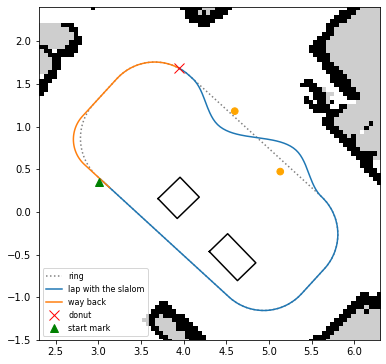

lap 6.76 m, 7.6 s at the profile; way back 2.40 m; tightest radius 0.32 m


In [2]:
m = yaml.safe_load(open(f'{MAPS}/room.yaml'))
img = np.array(Image.open(f'{MAPS}/room.pgm'))
res, ox, oy = m['resolution'], m['origin'][0], m['origin'][1]
ring = np.loadtxt(f'{MAPS}/room_track.csv', delimiter=',', skiprows=1)
on_map = lambda ax_, l: compose(TAPE, (ax_, l, 0))[:2]
cones = [on_map(1.39, 1.61), on_map(0.51, 1.72)]
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(img, cmap='gray', extent=(ox, ox + img.shape[1] * res, oy, oy + img.shape[0] * res))
ax.plot(ring[:, 1], ring[:, 2], ':', color='grey', label='ring')
ax.plot(path_out[:, 1], path_out[:, 2], label='lap with the slalom')
ax.plot(path_back[:, 1], path_back[:, 2], label='way back')
for k, (cx, cy) in enumerate(cones, 1):
    ax.add_patch(plt.Circle((cx, cy), CONE_R, color='orange'))
for a, b, d in ((0.62, 0.944, 0.36), (1.484, 1.959, 0.30)):     # the boxes from the start mark, as the lidar sees them
    corners = np.array([on_map(x, y) for x, y in ((a, 0.36), (b, 0.36), (b, 0.36 + d), (a, 0.36 + d), (a, 0.36))])
    ax.plot(corners[:, 0], corners[:, 1], 'k')
ax.plot(*path_out[-1, 1:3], 'rx', ms=10, label='donut')
ax.plot(*TAPE[:2], 'g^', ms=8, label='start mark')
ax.set_xlim(2.3, 6.3); ax.set_ylim(-1.5, 2.4); ax.set_aspect('equal'); ax.legend(loc='lower left', fontsize=8)
plt.show()
print(f'lap {path_out[-1, 0]:.2f} m, {np.sum(np.diff(path_out[:, 0]) / np.maximum(path_out[1:, 5], 0.05)):.1f} s at the profile; '
      f'way back {path_back[-1, 0]:.2f} m; tightest radius {1 / np.abs(path_out[:, 4]).max():.2f} m')

## The slalom

`nmpc_node` with `open_path` (the line ends: it stops there, exit code 0 only at the end) on AMCL. Each lap from the
start mark: the line error by AMCL (what the NMPC tracks), AMCL against the lidar path along and across the line,
and the cones: each a circle of 3.9 cm fitted on the points the run's own scans put on it, against the car's body.
`gymk_1` and `gymk_2` without cones, `gymk_3` with the cones 20 cm beside the line (it touched cone 1), from
`gymk_4` on moved out (cone 1 to ~14 cm, cone 2 ~12; cone 1 3 cm further in after `gymk_15`):

In [3]:
def line_error(x, y, p):
    k = np.argmin(np.hypot(p[:, 1] - x[:, None], p[:, 2] - y[:, None]), axis=1)
    return p[k, 0], -(x - p[k, 1]) * np.sin(p[k, 3]) + (y - p[k, 2]) * np.cos(p[k, 3]), k


def cone_centre(pts, guess):
    near = pts[np.hypot(pts[:, 0] - guess[0], pts[:, 1] - guess[1]) < 0.12]
    if len(near) < 20:
        return None
    return least_squares(lambda c: np.hypot(*(near - c).T) - CONE_R, near.mean(axis=0)).x


def lap(run, cones_at=None):
    t0, t1 = segments(run)[0]
    s = stretch(run, t0, min(t0 + 14.0, t1))
    a = read(run, 'amcl_pose')
    a = a[(a['t'] > t0) & (a['t'] < s['t'].iloc[-1])]
    sp, n, k = line_error(a['x'].to_numpy(), a['y'].to_numpy(), path_out)
    slalom = (sp > 4.4) & (sp < 6.4)
    # the lidar path on the map, at AMCL's times, against AMCL along and across the line
    lx, ly, lh = compose(TAPE, (np.interp(a['t'], s['t'], s['x']), np.interp(a['t'], s['t'], s['y']), 0))
    h = path_out[k, 3]
    ex, ey = a['x'].to_numpy() - lx, a['y'].to_numpy() - ly
    along, across = np.cos(h) * ex + np.sin(h) * ey, -np.sin(h) * ex + np.cos(h) * ey
    row = {'run': run, 'speed': 0.6 if run == 'gymk_1' else 1.0, 'line rms by AMCL [cm]': 100 * np.sqrt(np.mean(n ** 2)),
           'slalom max [cm]': 100 * np.abs(n[slalom]).max(), 'AMCL along [cm]': 100 * along.mean(), 'sd': 100 * along.std(),
           'AMCL across [cm]': 100 * across.mean(), 'sd ': 100 * across.std()}
    if cones_at:
        sc = read(run, 'scan')
        pts = []
        for _, mm in sc[(sc['t'] - 0.075 > s['t'].iloc[0]) & (sc['t'] - 0.075 < s['t'].iloc[-1])].iterrows():
            tm = mm['t'] - 0.075
            r = np.array(mm['ranges'], float); ang = mm['angle_min'] + np.arange(len(r)) * mm['angle_increment']
            ok = np.isfinite(r) & (r > 0.15) & (r < 1.0)
            x, y, hh = np.interp(tm, s['t'], s['x']), np.interp(tm, s['t'], s['y']), np.interp(tm, s['t'], s['psi'])
            px, py = r[ok] * np.cos(ang[ok]) + lidar_path.LIDAR_X, r[ok] * np.sin(ang[ok])
            pts.append(np.c_[x + np.cos(hh) * px - np.sin(hh) * py, y + np.sin(hh) * px + np.cos(hh) * py])
        pts = np.vstack(pts)
        for i, guess in enumerate(cones_at, 1):
            c = cone_centre(pts, guess)
            row[f'cone {i} [cm]'] = 100 * (min(np.hypot(*(body(x, y, hh) - c).T).min() for x, y, hh in s[['x', 'y', 'psi']].to_numpy()[::2]) - CONE_R)
    return row


FIRST, MOVED, LAST = [(1.39, 1.70), (0.47, 1.68)], [(1.39, 1.64), (0.51, 1.72)], [(1.39, 1.61), (0.51, 1.72)]
laps = pd.DataFrame([lap('gymk_1'), lap('gymk_2'), lap('gymk_3', FIRST), lap('gymk_4', MOVED), lap('gymk_6', MOVED), lap('gymk_10', MOVED),
                     lap('gymk_15', MOVED), lap('gymk_16', LAST), lap('gymk_17', LAST)]).set_index('run')
laps.round(1)

,speed,line rms by AMCL [cm],slalom max [cm],AMCL along [cm],sd,AMCL across [cm],sd,cone 1 [cm],cone 2 [cm]
run,,,,,,,,,
gymk_1,0.6,1.9,3.7,-4.8,5.8,-3.1,3.3,NaN,NaN
gymk_2,1.0,1.7,4.2,-5.7,6.3,-2.6,4.1,NaN,NaN
gymk_3,1.0,3.0,6.4,-6.4,8.8,0.4,5.2,-1.8,8.3
gymk_4,1.0,2.5,4.3,-6.3,8.0,-2.6,4.1,9.9,12.7
gymk_6,1.0,2.0,3.9,-8.2,6.6,-2.7,3.2,4.9,12.6
gymk_10,1.0,2.5,4.7,-3.7,8.9,-2.5,5.3,5.5,11.6
gymk_15,1.0,2.9,5.2,-3.5,6.0,-2.6,4.1,3.8,13.0
gymk_16,1.0,2.4,5.5,-6.8,10.0,-2.6,4.0,9.7,12.7
gymk_17,1.0,2.4,3.4,-7.5,8.3,-3.1,3.7,6.5,16.3


### Result

The NMPC holds AMCL on the line to 1.7-3.0 cm rms at full speed (1.9 at 60%), 3.4-6.4 cm at most in the
slalom. AMCL is 3.5-8.2 cm behind the lidar path along the line (+-6-10, its delay) and 2.5-3.1 cm right of it
(+-3-5; `gymk_3` +0.4), so the car runs ~3 cm left of the line: toward cone 1, away from cone 2. 20 cm beside the
line the body touched cone 1 (`gymk_3`); moved out, cone 1 came within 3.8-9.9 cm and cone 2 11.6-16.3 in six laps.

## The donut

`gap_node` with `donut_only`: from rest full lock and full throttle, the brake timed (as the parking's) so that
the car ends at its starting heading after one turn, the slide after the brake taken as 31 deg (`donut_slide`). The
wheels spin through it, so the odometry the localization runs on is wrong: at rest after it the node sets the
localization back where the donut started, turned by the gyro (0.25 m of spread), and asks it for six updates
without motion. The truth after the donut: the start mark, the lap's lidar path, the donut's. `gymk_11` lost its
reset (the node's map pose failed: fixed, 83a62e3), it was set by hand from this truth:

In [4]:
def phases(run):
    st = read(run, 'gap_state')
    change = st['phase'] != st['phase'].shift()
    return st.loc[change, ['t', 'phase']].to_numpy()


def donut(run, k, lap_end=None):
    t0, t_done = segments(run)[k]
    s = stretch(run, t0, t_done)
    r = np.gradient(s['psi'], s['t'])
    row = {'run': run, 'turned [deg]': np.degrees(s['psi'].iloc[-1]), 'yaw rate max': r.max(),
           'farthest [cm]': 100 * np.hypot(s['x'], s['y']).max(), 'ended [cm]': 100 * np.hypot(s['x'].iloc[-1], s['y'].iloc[-1])}
    if lap_end is not None:
        truth = compose(lap_end, (s['x'].iloc[-1], s['y'].iloc[-1], s['psi'].iloc[-1]))
        a = read(run, 'amcl_pose')
        after = a[a['t'] <= t_done + 0.5].iloc[-1]
        row['AMCL after the reset, off [cm]'] = 100 * np.hypot(after['x'] - truth[0], after['y'] - truth[1])
        row['heading off [deg]'] = (np.degrees(after['yaw'] - truth[2]) + 180) % 360 - 180
    return row


def lap_end(run):
    s = stretch(run, *segments(run)[0])
    return compose(TAPE, (s['x'].iloc[-1], s['y'].iloc[-1], s['psi'].iloc[-1]))


rows = [donut('gymk_7', 0, lap_end('gymk_6')), donut('gymk_11', 0)]
for run in ['gymk_15', 'gymk_16', 'gymk_17']:
    rows.append(donut(run, 1, lap_end(run)))
donuts = pd.DataFrame(rows).set_index('run')
donuts.round(1)

,turned [deg],yaw rate max,farthest [cm],ended [cm],"AMCL after the reset, off [cm]",heading off [deg]
run,,,,,,
gymk_7,347.3,4.0,48.3,24.3,9.1,-1.4
gymk_11,357.7,4.1,45.9,15.2,NaN,NaN
gymk_15,355.1,4.3,46.2,16.4,14.3,-1.3
gymk_16,353.6,4.4,49.1,22.0,13.0,-1.3
gymk_17,355.8,4.4,50.3,23.0,11.2,-1.2


### Result

Up to 4.0-4.4 rad/s: the car swings out to 46-50 cm from where it started and stops 15-24 cm from it, 2-13 deg
short of the turn (4-6 in the takes). Set back where the donut started, turned by the gyro, and updated at rest,
AMCL is 9-14 cm and 1.2-1.4 deg off the truth; the way back starts from there.

## The parking after the way back

The way back on AMCL, then the parking from where it stopped: the boxes from the scans at rest (the side's angle
from the densest line, `sideways.ipynb` frame), the line held up to the kick, which goes only with the car within
5 deg and 3 cm of it (`gymk_9` ran before: its kick then took the heading into account and came 7 deg off). The
arrival against the boxes, the kick (the node's), and the stop in the frame of the boxes:

In [5]:
def boxes(run, t):
    # the gap from the last five scans before t, the car at rest
    sc = read(run, 'scan')
    pts = []
    for _, mm in sc[sc['t'] < t].iloc[-5:].iterrows():
        r = np.array(mm['ranges'], float); ang = mm['angle_min'] + np.arange(len(r)) * mm['angle_increment']
        x, y = r * np.cos(ang) + lidar_path.LIDAR_X, r * np.sin(ang)
        ok = np.isfinite(r) & (x > -0.3) & (x < 2.5) & (y > 0.1) & (y < 1.2)
        pts.append(np.c_[x[ok], y[ok]])
    return find_gap(np.vstack(pts))


def parking(run):
    t0, t_end = segments(run)[-1]
    face, side, g_from, g_to = boxes(run, t0)
    f = np.radians(face)
    st = read(run, 'gap_state')
    kick = st[(st['phase'] == 3) & (st['t'] > t0)].iloc[0]
    s = stretch(run, t0, t_end)
    xb, yb, hb = np.cos(f) * s['x'] + np.sin(f) * s['y'], -np.sin(f) * s['x'] + np.cos(f) * s['y'], s['psi'] - f
    A, Bx = (g_from - 0.33, g_from, side, side + 0.36), (g_to, g_to + 0.475, side, side + 0.30)

    def dist(q, b):
        dx = np.maximum(np.maximum(b[0] - q[:, 0], q[:, 0] - b[1]), 0); dy = np.maximum(np.maximum(b[2] - q[:, 1], q[:, 1] - b[3]), 0)
        inside = (q[:, 0] > b[0]) & (q[:, 0] < b[1]) & (q[:, 1] > b[2]) & (q[:, 1] < b[3])
        return np.where(inside, -1.0, np.hypot(dx, dy)).min()

    mid = (FRONT + REAR) / 2
    return {'run': run, 'boxes against the car [deg]': face, 'line [cm]': 100 * (side + HALF + 0.02 - 0.42), 'to the kick [m]': (g_from + g_to - 0.12) / 2 - 0.30,
            'kick heading [deg]': np.degrees(kick['heading']), 'stop [deg]': np.degrees(hb.iloc[-1]),
            'middle against its aim [cm]': 100 * (xb.iloc[-1] + np.cos(hb.iloc[-1]) * mid - g_from - (g_to - g_from - 0.12) / 2),
            'box A [cm]': 100 * min(dist(body(x, y, h), A) for x, y, h in zip(xb, yb, hb)),
            'box B [cm]': 100 * min(dist(body(x, y, h), Bx) for x, y, h in zip(xb, yb, hb))}


parks = pd.DataFrame([parking(r) for r in ['gymk_9', 'gymk_14', 'gymk_15', 'gymk_16', 'gymk_17']]).set_index('run')
parks.round(1)

,boxes against the car [deg],line [cm],to the kick [m],kick heading [deg],stop [deg],middle against its aim [cm],box A [cm],box B [cm]
run,,,,,,,,
gymk_9,2.8,-13.7,0.7,-7.1,178.3,-8.2,-100.0,10.2
gymk_14,8.8,-1.0,0.6,1.7,187.8,-5.2,1.1,6.1
gymk_15,6.2,-0.3,0.6,1.5,185.5,-1.5,5.1,2.8
gymk_16,4.9,0.1,0.6,1.7,186.7,-0.7,5.6,3.9
gymk_17,2.5,-5.2,0.6,-1.5,184.0,-0.6,5.9,2.9


A box at -100 is a body inside its outline: `gymk_9` touched box A.

In the takes the way back left the boxes 2.5-6.2 deg off. The boxes seen from the start mark before the lap and where
the way back stopped, and the localization there against the end of the way back (the newest AMCL correction on the
newest odometry, as the NMPC takes it):

In [6]:
def localization(run, t):
    # the map pose at t as the NMPC takes it
    a, o = read(run, 'amcl_pose'), read(run, 'odometry_filtered')
    e = a[a['t'] < t].iloc[-1]
    k = np.argmin(np.abs(o['stamp'] - e['stamp']))
    c = compose((e['x'], e['y'], e['yaw']), compose((0, 0, -o['yaw'].iloc[k]), (-o['x'].iloc[k], -o['y'].iloc[k], 0)))
    q = o[o['t'] < t].iloc[-1]
    return compose(c, (q['x'], q['y'], q['yaw']))


def arrival(run):
    seg = segments(run)
    t_park = seg[-1][0]
    x, y, h = localization(run, t_park)
    end = path_back[-1]
    return {'run': run, 'boxes from the start mark [deg]': boxes(run, seg[0][0])[0], 'at the arrival [deg]': boxes(run, t_park)[0],
            'localization off the path [deg]': (np.degrees(h - end[3]) + 180) % 360 - 180,
            'along [cm]': 100 * (np.cos(end[3]) * (x - end[1]) + np.sin(end[3]) * (y - end[2])),
            'across [cm]': 100 * (-np.sin(end[3]) * (x - end[1]) + np.cos(end[3]) * (y - end[2]))}


print(f"the way back ends on the ring's near straight, {np.degrees(path_back[-1, 3] - TAPE[2]) % 360:.1f} deg from the start mark's heading")
pd.DataFrame([arrival(r) for r in ['gymk_15', 'gymk_16', 'gymk_17']]).set_index('run').round(1)

the way back ends on the ring's near straight, 3.4 deg from the start mark's heading


,boxes from the start mark [deg],at the arrival [deg],localization off the path [deg],along [cm],across [cm]
run,,,,,
gymk_15,-0.4,6.2,-8.0,7.2,1.5
gymk_16,-0.8,4.9,-8.1,6.9,1.6
gymk_17,-0.3,2.5,-5.5,5.9,2.1


Over the last 1.2 m of the way back, by that localization: the heading off the path and the steering command
(0.52 full lock):

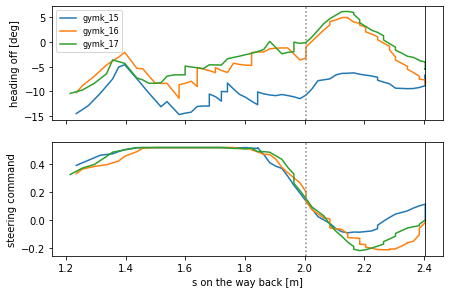

the last corner ends at 2.00 m, the path at 2.40


In [7]:
def approach(run):
    t0, t1 = segments(run)[2]
    o, d = read(run, 'odometry_filtered'), read(run, 'drive')
    rows = []
    for t in o.loc[(o['t'] > t0) & (o['t'] < t1), 't'].to_numpy()[::2]:
        x, y, h = localization(run, t)
        i = np.argmin(np.hypot(path_back[:, 1] - x, path_back[:, 2] - y))
        rows.append((path_back[i, 0], (np.degrees(h - path_back[i, 3]) + 180) % 360 - 180, d.loc[d['t'] <= t, 'cmd_steer'].iloc[-1]))
    return pd.DataFrame(rows, columns=['s', 'off', 'steer'])


arc_end = path_back[np.abs(path_back[:, 4]) > 1.0, 0].max()
fig, ax = plt.subplots(2, 1, figsize=(7, 4.5), sharex=True)
for run in ['gymk_15', 'gymk_16', 'gymk_17']:
    a = approach(run)
    a = a[a['s'] > path_back[-1, 0] - 1.2]
    ax[0].plot(a['s'], a['off'], label=run)
    ax[1].plot(a['s'], a['steer'])
for x in ax:
    x.axvline(arc_end, color='grey', ls=':')
    x.axvline(path_back[-1, 0], color='k', lw=0.8)
ax[0].set_ylabel('heading off [deg]'); ax[1].set_ylabel('steering command'); ax[1].set_xlabel('s on the way back [m]')
ax[0].legend(fontsize=8)
plt.show()
print(f'the last corner ends at {arc_end:.2f} m, the path at {path_back[-1, 0]:.2f}')

### Result

From `gymk_14` on, the kick waiting for the line: the boxes 2.5-8.8 deg off the car where the way back stopped,
1.5-1.7 deg at the kick 0.6 m later. The slides turned 4-8 deg too far (184.0-187.8 deg), the middle of the car
0.6-5.2 cm short of its aim, the body 1.1-5.9 cm from box A (1.1 the most skewed, `gymk_14`) and 2.8-6.1 from box B;
in the takes 5.1-5.9 and 2.8-3.9.

The skew is the way back's. Seen from the start mark the boxes are within 1 deg of the car, at the arrival 2.5-6.2.
By its own localization the NMPC stopped 5.5-8.1 deg off the end of its path, 6-7 cm past it. Through the last
corner (R 0.4) the steering was at full lock and the car 2-15 deg behind the path; after it `gymk_16` and `gymk_17`
swung 5-6 deg over and were coming back when the path ended 0.4 m later, `gymk_15` never caught up. And the path
ends on the ring's near straight, 3.4 deg off the start mark's heading the boxes are set on. Next: the way back onto
the start mark's line, slower at its end.

## The whole take

`gymkhana.launch.py`, the car armed on the start mark, nothing touched until the end; `gymk_17` with the slide after
the parking's brake taken as 41 deg (36.4 the others). The time from the first turn of the wheels to the last, and
the pauses between the steps (a node starting, the gyro's bias at rest, the localization's updates):

In [8]:
rows = []
for run in ['gymk_15', 'gymk_16', 'gymk_17']:
    j = read(run, 'joint_states')
    moving = ((j['wl'] + j['wr']).abs() > 0.05).to_numpy()
    seg = segments(run)
    # each step's wheels turning: from its start to the last turning sample before the next
    ends = [j['t'].to_numpy()[(j['t'] < b).to_numpy() & moving][-1] for a, b in seg]
    rows.append({'run': run, 'steps': len(seg), 'take [s]': ends[-1] - seg[0][0],
                 'pauses [s]': ', '.join(f'{seg[i + 1][0] - ends[i]:.1f}' for i in range(len(seg) - 1))})
takes = pd.DataFrame(rows).set_index('run')
takes.join(laps[['cone 1 [cm]', 'cone 2 [cm]']]).join(parks[['stop [deg]', 'middle against its aim [cm]', 'box A [cm]', 'box B [cm]']]).round(1)

,steps,take [s],pauses [s],cone 1 [cm],cone 2 [cm],stop [deg],middle against its aim [cm],box A [cm],box B [cm]
run,,,,,,,,,
gymk_15,4,29.7,"2.5, 4.6, 4.0",3.8,13.0,185.5,-1.5,5.1,2.8
gymk_16,4,31.2,"3.0, 5.2, 3.7",9.7,12.7,186.7,-0.7,5.6,3.9
gymk_17,4,31.1,"4.3, 5.2, 2.3",6.5,16.3,184.0,-0.6,5.9,2.9


### Result

Three takes in a row, 29.7-31.2 s from the first turn of the wheels to the last, the car not touched in between.
11-12 s of it are the pauses between the steps, 2.3-5.2 s each. Cones 3.8-9.7 and 12.7-16.3 cm, parked at
184.0-186.7 deg with the middle within 1.5 cm of its aim, 5.1-5.9 cm from box A and 2.8-3.9 from box B.